In [24]:
!python --version

Python 3.12.13


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("/content/drive/MyDrive/Job_1_resource_world_population.csv")

In [27]:
#9. perform initial inspection
df.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country/Territory            234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area (km²)          

In [29]:
df.isnull().sum()

,0
Rank,0
CCA3,0
Country/Territory,0
Capital,0
Continent,0
2022 Population,0
2020 Population,0
2015 Population,0
2010 Population,0
2000 Population,0


In [30]:
#10. mean, median, varinace, and standard deviation
stats = df.groupby("Continent")["2022 Population"].agg(
    mean="mean",
    median="median",
    variance="var",
    std_dev="std"
)

stats

,mean,median,variance,std_dev
Continent,,,,
Africa,2.503037e+07,13352864.0,1.411678e+15,3.757230e+07
Asia,9.442767e+07,18082920.0,7.824368e+16,2.797207e+08
Europe,1.486295e+07,5228714.0,7.433757e+14,2.726492e+07
North America,1.500740e+07,236399.0,3.182998e+15,5.641806e+07
Oceania,1.958198e+06,114164.0,3.311927e+13,5.754935e+06
South America,3.120119e+07,15112555.0,3.105366e+15,5.572581e+07


In [10]:
df.columns

Index(['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent',
       '2022 Population', '2020 Population', '2015 Population',
       '2010 Population', '2000 Population', '1990 Population',
       '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)',
       'Growth Rate', 'World Population Percentage'],
      dtype='object')

In [31]:
#11. calculate cumulative population
year_cols = [col for col in df.columns if "Population" in col]

df["Cumulative_Population"] = df[year_cols].sum(axis=1)
df[["Country/Territory", "Cumulative_Population"]].head()

,Country/Territory,Cumulative_Population
0,Afghanistan,1.955216e+08
1,Albania,2.324852e+07
2,Algeria,2.525824e+08
3,American Samoa,3.626880e+05
4,Andorra,4.759260e+05


In [32]:
df.columns

Index(['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent',
       '2022 Population', '2020 Population', '2015 Population',
       '2010 Population', '2000 Population', '1990 Population',
       '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)',
       'Growth Rate', 'World Population Percentage', 'Cumulative_Population'],
      dtype='object')

In [33]:
# 12. change the column names
new_columns = {}

for col in df.columns:
    if "Population" in col:
        new_columns[col] = col.split()[0]

df.rename(columns=new_columns, inplace=True)

# Result
df.columns

Index(['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent', '2022',
       '2020', '2015', '2010', '2000', '1990', '1980', '1970', 'Area (km²)',
       'Density (per km²)', 'Growth Rate', 'World', 'Cumulative_Population'],
      dtype='object')

In [34]:
#13. save the cleanest dataset
df.to_csv("processed_data.csv", index=False)

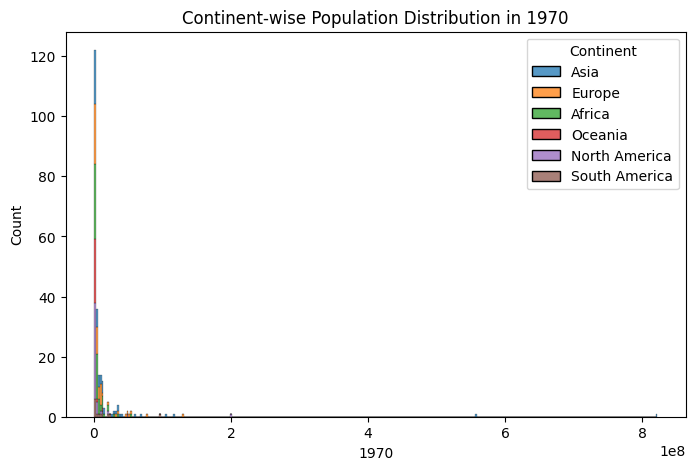

In [35]:
#14. visualizing continent-wise population
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="1970", hue="Continent", multiple="stack")
plt.title("Continent-wise Population Distribution in 1970")
plt.savefig('Continent-wise Population Distribution in 1970.png')
plt.show()

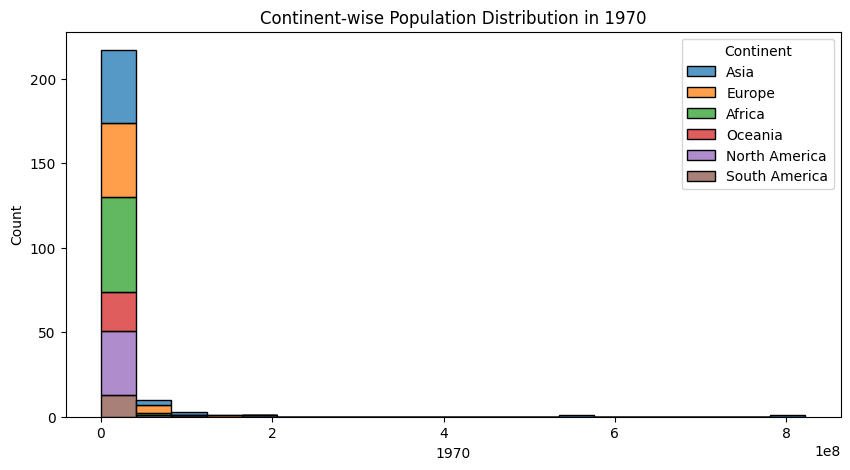

In [36]:
plt.figure(figsize=(10,5))   # increasing figure width
sns.histplot(
    data=df,
    x="1970",
    hue="Continent",
    multiple="stack",
    bins=20
)
plt.title("Continent-wise Population Distribution in 1970")
plt.savefig('Continent-wise Population Distribution in 1970_width.png')
plt.show()

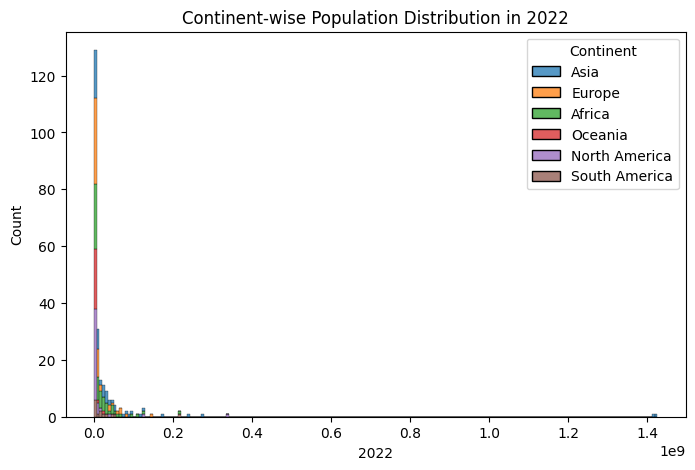

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="2022", hue="Continent", multiple="stack")
plt.title("Continent-wise Population Distribution in 2022")
plt.savefig('Continent-wise Population Distribution in 2022.png')
plt.show()

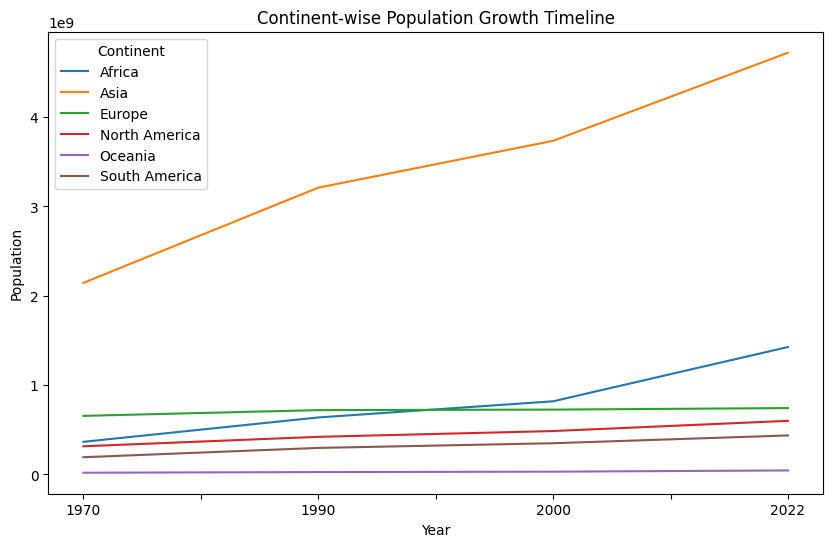

In [37]:
#15. statistical reasoning
timeline = df.groupby("Continent")[["1970", "1990", "2000", "2022"]].sum()

timeline.T.plot(figsize=(10,6))
plt.title("Continent-wise Population Growth Timeline")
plt.xlabel("Year")
plt.ylabel("Population")
plt.savefig('Continent-wise Population Growth Timeline.png')
plt.show()

In [38]:
#16. correlation
corr_matrix = df.select_dtypes(include=np.number).corr()
corr_matrix

,Rank,2022,2020,2015,2010,2000,1990,1980,1970,Area (km²),Density (per km²),Growth Rate,World,Cumulative_Population
Rank,1.000000,-0.358361,-0.355854,-0.351222,-0.347461,-0.341057,-0.336152,-0.335246,-0.335379,-0.383774,0.129436,-0.224561,-0.358464,-0.347946
2022,-0.358361,1.000000,0.999946,0.999490,0.998629,0.994605,0.987228,0.980285,0.973162,0.453411,-0.027618,-0.020863,0.999999,0.996834
2020,-0.355854,0.999946,1.000000,0.999763,0.999105,0.995583,0.988724,0.982121,0.975254,0.454993,-0.027358,-0.025116,0.999944,0.997561
2015,-0.351222,0.999490,0.999763,1.000000,0.999783,0.997340,0.991594,0.985724,0.979414,0.458240,-0.026857,-0.032154,0.999487,0.998778
2010,-0.347461,0.998629,0.999105,0.999783,1.000000,0.998593,0.993929,0.988786,0.983042,0.461936,-0.026505,-0.037983,0.998626,0.999521
2000,-0.341057,0.994605,0.995583,0.997340,0.998593,1.000000,0.998336,0.995160,0.990956,0.473933,-0.026139,-0.050515,0.994598,0.999662
1990,-0.336152,0.987228,0.988724,0.991594,0.993929,0.998336,1.000000,0.999042,0.996602,0.486764,-0.026224,-0.062397,0.987218,0.996730
1980,-0.335246,0.980285,0.982121,0.985724,0.988786,0.995160,0.999042,1.000000,0.999194,0.498166,-0.026587,-0.072349,0.980273,0.992832
1970,-0.335379,0.973162,0.975254,0.979414,0.983042,0.990956,0.996602,0.999194,1.000000,0.509940,-0.026881,-0.081313,0.973150,0.988121
Area (km²),-0.383774,0.453411,0.454993,0.458240,0.461936,0.473933,0.486764,0.498166,0.509940,1.000000,-0.063128,-0.013970,0.453284,0.471739


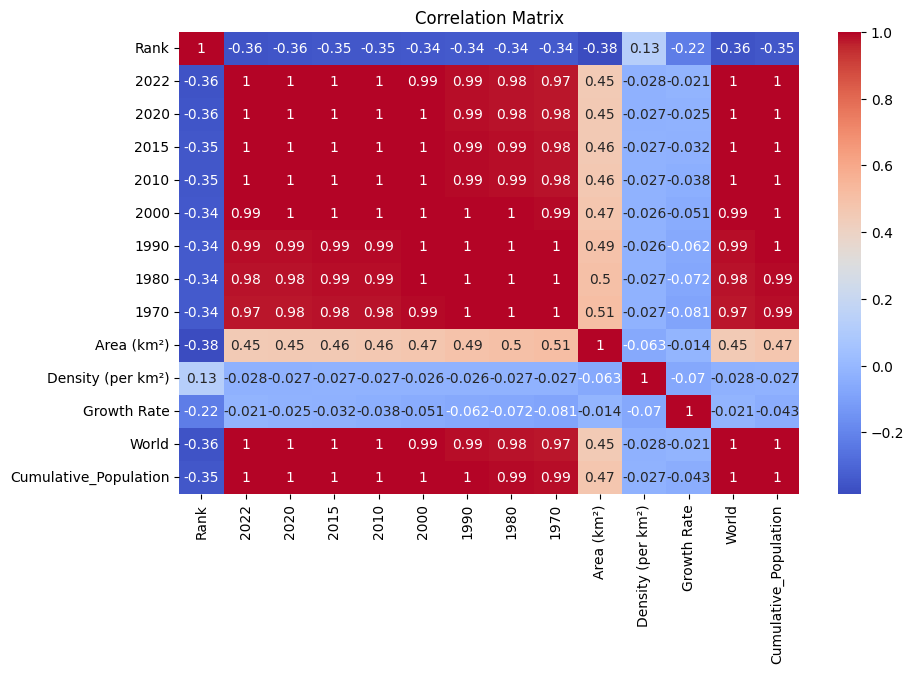

In [39]:
#16. visualize
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig('Correlation Matrix.png')
plt.show()